## Install dependencies

In [9]:
# # Install dependencies
# !pip install -q "spacy>=3.8.0" "thinc>=8.3.0"
# !pip install -q cupy-cuda12x
# !python -m spacy download en_core_web_trf
# print("Done. Restart the session before continuing.")

## Import libraries and load spaCy model

In [10]:
import ast, json, math, time, os
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import deque
import string
import numpy as np
import pandas as pd
import spacy
from tqdm.auto import tqdm
import spacy
import spacy_curated_transformers
import re
from spacy.lang.en import English
from tqdm import tqdm

spacy.require_gpu()
nlp = spacy.load("en_core_web_trf")
print("Loaded successfully")
print(f"spaCy {spacy.__version__} loaded — model: en_core_web_trf")
print("GPU active")

Loaded successfully
spaCy 3.8.14 loaded — model: en_core_web_trf
GPU active


In [11]:
# import pandas as pd

# def parse_tech_ids(raw):
#     if isinstance(raw, list):
#         return raw
#     if isinstance(raw, str):
#         raw = raw.strip()
#         if raw.startswith("["):
#             try:
#                 return ast.literal_eval(raw)
#             except Exception:
#                 return [raw]
#         return [raw] if raw else []
#     if isinstance(raw, float) and not math.isnan(raw):
#         return [str(int(raw))]
#     return []



# # Load original file
# df = pd.read_excel(
#     "/kaggle/input/datasets/worldseeker/content/cve_single_technique.xlsx"
# )

# # Standard cleanup
# df["MITRE_Technique_Numbers"] = (
#     df["MITRE_Technique_Numbers"]
#     .astype(str)
#     .str.strip()
# )

# # Fix known typos
# df["MITRE_Technique_Numbers"] = df["MITRE_Technique_Numbers"].replace({
#     "TT1565": "T1565",
#     "T11190": "T1190"
# })

# # Handle malformed combined technique
# bad = df[df["MITRE_Technique_Numbers"] == "T1190. T1005"]

# if len(bad) > 0:
#     df = df[df["MITRE_Technique_Numbers"] != "T1190. T1005"]

#     extra_rows = pd.concat([
#         bad.assign(MITRE_Technique_Numbers="T1190"),
#         bad.assign(MITRE_Technique_Numbers="T1005")
#     ])

#     df = pd.concat([df, extra_rows], ignore_index=True)

# # Remove string "nan" if present
# df = df[df["MITRE_Technique_Numbers"] != "nan"]
# df = df.reset_index(drop=True)
# sample_raw = df["MITRE_Technique_Numbers"].iloc[0]
# print(f"Raw   : {sample_raw!r}")
# print(f"Parsed: {parse_tech_ids(sample_raw)}")
# # Save cleaned version
# output_file = "/kaggle/working/cve_single_technique_cleaned.xlsx"
# df.to_excel(output_file, index=False)

# print(f"Saved: {output_file}")
# print("Rows:", len(df))

In [12]:
def clean_text(text: str) -> str:
    # 1. Remove markdown links
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    # 2. Remove citation tags
    text = re.sub(r'\(Citation:[^)]+\)', '', text)
    # 3. Strip code tags — keep content
    text = re.sub(r'<code>(.*?)</code>', r'\1', text)
    # 4. Strip markdown headers — keep title
    text = re.sub(r'(?m)^#{1,6}\s+(.+)$', r'\1.', text)
    # 5. Strip bullet markers — keep content
    text = re.sub(r'^\s*[\*\-\+]\s+', '', text, flags=re.MULTILINE)
    # 6. Remove CVSS vectors
    text = re.sub(r'CVSS:\d+\.\d+[/A-Z:0-9.]+', '', text)
    # 7. ← NEW: remove acronym parentheticals only — "(UAC)", "(BYOVD)", "(NVD)"
    text = re.sub(r'\(([^)]+)\)', r'\1', text)

    # 7c. "(i.e. Exploits)" → "Exploits"
    text = re.sub(r'\(\s*(?:i\.e\.|e\.g\.)\s*([^)]+)\)', r'\1', text, flags=re.IGNORECASE)
    # 8. Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# ── Load files ──────────────────────────────────────────────────────────────
smet_df   = pd.read_excel("/kaggle/input/datasets/worldseeker/content/CVE_annotated_dataset.xlsx")
attack_df = pd.read_excel("/kaggle/input/datasets/worldseeker/content/enterprise-attack-v17.1.xlsx")

# ── Build name → T-ID lookup ────────────────────────────────────────────────
name_to_id = dict(zip(
    attack_df["name"].str.strip(),
    attack_df["ID"].str.strip()
))

# ── Parse technique name lists ───────────────────────────────────────────────
def parse_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

smet_df["ATT&CK Techniques"] = smet_df["ATT&CK Techniques"].apply(parse_list)

# ── Explode to one row per CVE-Technique pair ────────────────────────────────
expanded = smet_df.explode("ATT&CK Techniques").reset_index(drop=True)

# ── Map technique name → T-ID ────────────────────────────────────────────────
expanded["MITRE_Technique_Numbers"] = (
    expanded["ATT&CK Techniques"].str.strip().map(name_to_id)
)

# ── Drop rows where mapping failed ──────────────────────────────────────────
missing = expanded["MITRE_Technique_Numbers"].isna().sum()
if missing:
    print(f"[Warning] {missing} rows had no T-ID match — dropped")
    print(expanded[expanded["MITRE_Technique_Numbers"].isna()]["ATT&CK Techniques"].unique())
expanded = expanded.dropna(subset=["MITRE_Technique_Numbers"]).reset_index(drop=True)

# ── Rename to match your pipeline format exactly ─────────────────────────────
smet_converted = expanded.rename(columns={
    "ID":          "CVE_ID",
    "Description": "CVE_Description",
})[["CVE_ID", "CVE_Description", "MITRE_Technique_Numbers"]]

# ── Save ──────────────────────────────────────────────────────────────────────
OUTPUT = "/kaggle/working/smet_converted.xlsx"
smet_converted.to_excel(OUTPUT, index=False)

print(f"Rows    : {len(smet_converted)}")
print(f"CVEs    : {smet_converted['CVE_ID'].nunique()}")
print(f"T-IDs   : {smet_converted['MITRE_Technique_Numbers'].nunique()}")
print(f"Saved → {OUTPUT}")
print()
print(smet_converted.head(10).to_string())

[Warning] 2 rows had no T-ID match — dropped
['Indicator Removal on Host' 'Browser Extensions']
Rows    : 444
CVEs    : 301
T-IDs   : 39
Saved → /kaggle/working/smet_converted.xlsx

           CVE_ID                                                                                                                                                                                                                                                                                                                                                                                                          CVE_Description MITRE_Technique_Numbers
0  CVE-2021-29665                                                                                                                                                                                                 IBM Security Verify Access 20.07 is vulnerable to a stack based buffer overflow, caused by improper bounds checking which could allow a local attacker to exe

## Load CVE and Technique datasets

In [13]:
CVE_FILE       = "/kaggle/working/smet_converted.xlsx"
TECHNIQUE_FILE = "/kaggle/input/datasets/worldseeker/content/techniques.xlsx"

df_cve  = pd.read_excel(CVE_FILE)
df_tech = pd.read_excel(TECHNIQUE_FILE)
df_tech.columns = ["Technique_ID", "Technique_Description"]

# Technique lookup dict: ID -> description
tech_dict = dict(zip(df_tech["Technique_ID"], df_tech["Technique_Description"]))

print(f"CVE rows   : {len(df_cve)}")
print(f"Techniques : {len(tech_dict)}")
print()
display(df_cve.head(15))

CVE rows   : 444
Techniques : 679



,CVE_ID,CVE_Description,MITRE_Technique_Numbers
0,CVE-2021-29665,IBM Security Verify Access 20.07 is vulnerable...,T1068
1,CVE-2018-8440,An elevation of privilege vulnerability exists...,T1068
2,CVE-2021-3561,An Out of Bounds flaw was found fig2dev versio...,T1499
3,CVE-2021-26966,A remote authenticated sql injection vulnerabi...,T1565
4,CVE-2021-26966,A remote authenticated sql injection vulnerabi...,T1190
5,CVE-2019-13522,An attacker could use a specially crafted proj...,T1068
6,CVE-2016-7189,The Chakra JavaScript engine in Microsoft Edge...,T1189
7,CVE-2008-4996,** DISPUTED ** init in initramfs-tools 0.92f ...,T1485
8,CVE-2008-4996,** DISPUTED ** init in initramfs-tools 0.92f ...,T1078
9,CVE-2015-2419,JScript 9 in Microsoft Internet Explorer 10 an...,T1203


## Build positive and negative CVE-Technique pairs. For each CVE, every mapped technique becomes a positive pair (label=1). Negative labels are assigned to TF-IDF mined hard negative and random negative (50/50)

In [14]:


#  Config 
NEG_PER_TECHNIQUE = 3    # NEG_PER_CVE
HARD_RATIO        = 0.50
TOP_K_POOL        = 20
SIM_UPPER         = 0.90
np.random.seed(42)

# Fit TF-IDF over all technique texts 
tech_ids       = list(tech_dict.keys())
tech_texts     = [tech_dict[t] for t in tech_ids]
vectorizer     = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
tech_matrix    = vectorizer.fit_transform(tech_texts)
tech_id_to_idx = {tid: i for i, tid in enumerate(tech_ids)}

# Group by CVE 
grouped = (
    df_cve.groupby("CVE_ID", as_index=False)
          .agg({
              "CVE_Description": "first",
              "MITRE_Technique_Numbers": list
          })
)
print(f"Unique CVEs: {len(grouped)}  |  Total positive rows: {len(df_cve)}")

# Build pairs 
pairs = []

for _, row in tqdm(grouped.iterrows(), total=len(grouped), desc="Building pairs"):
    cve_id   = row["CVE_ID"]
    cve_text = clean_text(row["CVE_Description"])  
    pos_ids  = [t for t in row["MITRE_Technique_Numbers"] if t in tech_dict]
    pos_set  = set(pos_ids)

    # Positives 
    for tid in pos_ids:
        pairs.append({"CVE_ID": cve_id, "CVE_text": cve_text,
                      "Technique_ID": tid, "Technique_text": tech_dict[tid],
                      "label": 1})

    #  Negative pool (excludes ALL true techniques) 
    neg_pool_ids = [t for t in tech_ids if t not in pos_set]
    if not neg_pool_ids:
        continue

    #  Total negatives scaled to number of techniques
    total_neg = NEG_PER_TECHNIQUE * len(pos_ids)
    hard_neg  = max(1, round(total_neg * HARD_RATIO))

    #  Hard negatives via TF-IDF 
    hard_tids = []
    if len(neg_pool_ids) >= hard_neg:
        cve_vec     = vectorizer.transform([cve_text])
        neg_indices = [tech_id_to_idx[t] for t in neg_pool_ids]
        sims        = cosine_similarity(cve_vec, tech_matrix[neg_indices]).flatten()

        ranked     = np.argsort(sims)[::-1]
        candidates = [neg_pool_ids[i] for i in ranked
                      if sims[i] < SIM_UPPER][:TOP_K_POOL]
        if candidates:
            hard_tids = list(np.random.choice(candidates,
                                              min(hard_neg, len(candidates)),
                                              replace=False))

    #  Random negatives to fill up to total_neg 
    n_rand_needed = total_neg - len(hard_tids)
    rand_pool     = [t for t in neg_pool_ids if t not in hard_tids]
    rand_tids     = []
    if n_rand_needed > 0 and rand_pool:
        rand_tids = list(np.random.choice(rand_pool,
                                          min(n_rand_needed, len(rand_pool)),
                                          replace=False))

    for tid in hard_tids + rand_tids:
        pairs.append({"CVE_ID": cve_id, "CVE_text": cve_text,
                      "Technique_ID": tid, "Technique_text": tech_dict[tid],
                      "label": 0})

#  Stats 
pos = sum(p["label"] for p in pairs)
print(f"Total pairs : {len(pairs)}  (pos={pos}  neg={len(pairs)-pos})")

Unique CVEs: 301  |  Total positive rows: 444


Building pairs: 100%|██████████| 301/301 [00:01<00:00, 189.68it/s]

Total pairs : 1776  (pos=444  neg=1332)


## Split CVE and Technique texts into sentences

In [15]:
# sentence splitter
sentencizer = English()
sentencizer.add_pipe("sentencizer")

def split_sentences(text):
    text = clean_text(text)
    return [
        s.text.strip()
        for s in sentencizer(text).sents
        if s.text.strip()
    ]


# Sentence splitting
for pair in tqdm(pairs, desc="Sentence splitting"):
    pair["CVE_sentences"] = split_sentences(pair["CVE_text"])
    pair["Technique_sentences"] = split_sentences(pair["Technique_text"])

# Preview
p = pairs[0]
print("CVE sentences:")
print(p["CVE_sentences"])
print("\nTechnique sentences:")
print(p["Technique_sentences"])

Sentence splitting: 100%|██████████| 1776/1776 [00:01<00:00, 973.50it/s] 

CVE sentences:
['** DISPUTED ** init in initramfs-tools 0.92f allows local users to overwrite arbitrary files via a symlink attack on the /tmp/initramfs.debug temporary file.', 'NOTE: the vendor disputes this vulnerability, stating that "init is [used in] a single-user context; there\'s no possibility that this is exploitable."']

Technique sentences:
['Adversaries may destroy data and files on specific systems or in large numbers on a network to interrupt availability to systems, services, and network resources.', 'Data destruction is likely to render stored data irrecoverable by forensic techniques through overwriting files or data on local and remote drives.', 'Common operating system file deletion commands such as del and rm often only remove pointers to files without wiping the contents of the files themselves, making the files recoverable by proper forensic methodology.', "This behavior is distinct from Disk Content Wipe and Disk Structure Wipe because individual files are destro

## PropBank role map and BIO span helpers. These constants and two small functions are shared by the SRL extraction in the next cell.

In [16]:
PROPBANK_ROLE_MAP = {
    "ARG0": "subject", "ARG1": "object", "ARG2": "indirect-object",
    "ARG3": "beneficiary", "ARG4": "endpoint",
    "ARGM-MNR": "manner", "ARGM-TMP": "time", "ARGM-LOC": "location",
    "ARGM-CAU": "cause", "ARGM-NEG": "negation", "ARGM-MOD": "modal",
    "ARGM-ADV": "adverbial", "ARGM-PRP": "purpose", "V": "verb",
}

TEMPORAL_ENT_TYPES = {"DATE", "TIME", "DURATION", "SET"}

ROLE_TAG_MAP = {
    "subject":         ("<SUB>",  "</SUB>"),
    "object":          ("<OBJ>",  "</OBJ>"),
    "verb":            ("<VRB>",  "</VRB>"),
    "manner":          ("<MNR>",  "</MNR>"),
    "location":        ("<LOC>",  "</LOC>"),
    "time":            ("<TMP>",  "</TMP>"),
    "cause":           ("<CAU>",  "</CAU>"),
    "negation":        ("<NEG>",  "</NEG>"),
    "modal":           ("<MOD>",  "</MOD>"),
    "adverbial":       ("<ADV>",  "</ADV>"),
    "purpose":         ("<PRP>",  "</PRP>"),
    "indirect-object": ("<OB2>",  "</OB2>"),
    "beneficiary":     ("<BNF>",  "</BNF>"),
    "endpoint":        ("<EPT>",  "</EPT>"),
}



def reconstruct_spans(words, tags):
    """BIO tag sequence -> [(propbank_role, span_text), ...]"""
    spans, cur_role, cur_tokens = [], None, []
    def flush():
        if cur_role and cur_tokens:
            spans.append((cur_role, " ".join(cur_tokens)))
    for word, tag in zip(words, tags):
        if tag == "O":
            flush(); cur_role, cur_tokens = None, []
        elif tag.startswith("B-"):
            flush(); cur_role = tag[2:]; cur_tokens = [word]
        elif tag.startswith("I-") and cur_role == tag[2:]:
            cur_tokens.append(word)
        else:
            flush(); cur_role = tag[2:] if tag.startswith("I-") else None
            cur_tokens = [word] if cur_role else []
    flush()
    return spans


def spans_to_markup(spans):
    parts = []
    for pb_role, text in spans:
        canonical = PROPBANK_ROLE_MAP.get(pb_role)
        if canonical and text.strip():
            open_tag, close_tag = ROLE_TAG_MAP.get(canonical, (f"<{canonical}>", f"</{canonical}>"))
            parts.append(f"{open_tag} {text.strip()} {close_tag}")
    return " ".join(parts)

## Extract SRL frames using spaCy dependency parse. For each verbal predicate in a sentence, we walk its dependency children and assign PropBank roles (ARG0=subject, ARG1=object, ARGM-TMP=time, etc.). The result for each sentence is a `structured` role dict and a readable `markup` string.

In [17]:
SPATIAL_PREPS = {
    "in", "on", "at", "within", "inside", "outside", "under", "over",
    "above", "below", "between", "among", "into", "onto", "across",
    "around", "behind", "beside", "near", "against", "throughout", "for"
}

MANNER_PREPS = {
    "by", "via", "through", "using", "with", "without", "as", "per"
}

ALL_PREPS = SPATIAL_PREPS.union(MANNER_PREPS)

TEMPORAL_WORDS = {
    'after', 'before', 'during', 'when', 'while', 'once', 'until',
    'since', 'later', 'earlier', 'then', 'now', 'previously',
    'initially', 'subsequently', 'immediately', 'recently',
    'always', 'never', 'often',
    'monday', 'tuesday', 'wednesday', 'thursday', 'friday',
    'saturday', 'sunday',
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'today', 'yesterday', 'tomorrow',
    'hourly', 'daily', 'weekly', 'monthly'
}
LIGHT_VERBS = {
            "be", "is", "are", "was", "were",
            "am", "been", "being",
            "note", "include"
        }
MAIN_PRED_DEPS = {"ROOT", "conj"}

STOPWORDS = {
    "a", "an", "the", "this", "that", "these", "those",
    "it", "its", "itself", "they", "them", "their",
    "which", "who", "whom", "what", "where", "when",
    "he", "she", "we", "i", "you", "my", "our", "your",
    "such", "some", "any", "all", "each", "both",
    "also", "just", "only", "then", "than", "so",
}

ADVERB_MODIFIER_ROLES = {"ARGM-MNR", "ARGM-TMP", "ARGM-ADV", "ARGM-NEG"}

def _modifier_span_is_worth_keeping(role: str, text: str, doc_tokens: list) -> bool:
    """
    Modifier spans (MNR, TMP, ADV) must have at least one meaningful token.
    Core args (ARG0/ARG1/ARG2) are always kept, already gated upstream.
    """
    if role not in ADVERB_MODIFIER_ROLES:
        return True   # core arg (always keep)
    return _is_meaningful_span(text, doc_tokens)

MIN_ARG_TOKENS  = 1    # single-token cyber entities are valid (PowerShell, ETW, syslog)
MIN_ARG_ROLES   = 1    # still need at least one non-verb argument
MAX_FRAMES_SENT = 4
CORE_ROLES = {"ARG0", "ARG1", "ARG2"}   # structural arguments only; modifiers don't count

def _is_meaningful_span(text: str, doc_span_tokens=None) -> bool:
    """
    Uses linguistic signals from spaCy rather than a hardcoded list.
    doc_span_tokens: list of spaCy Token objects for the span (optional).
    Falls back to surface heuristics when tokens unavailable.
    """
    if doc_span_tokens:
        for tok in doc_span_tokens:
            # NER already handles PowerShell, ETW, LSASS etc.
            if tok.ent_type_:
                return True
            # Proper noun catches capitalized tool names NER misses
            if tok.pos_ == "PROPN":
                return True
            # All-caps short token protocol/API acronyms: WMI, RDP, DLL
            if tok.text.isupper() and len(tok.text) >= 2:
                return True
            # Content noun that isn't a stopword
            if tok.pos_ == "NOUN" and not tok.is_stop and not tok.is_punct:
                return True
        return False

    # Fallback: surface heuristics only (no spaCy tokens available)
    tokens = [t.strip(string.punctuation) for t in text.split() if t.strip(string.punctuation)]
    content = [t for t in tokens if t.lower() not in STOPWORDS]
    return len(content) >= MIN_ARG_TOKENS


def reconstruct_spans_with_tokens(words, tags, doc):
    spans = []
    cur_role, cur_tokens, cur_doc_tokens, cur_pos = None, [], [], []

    def flush():
        if cur_role and cur_tokens:
            clean = " ".join(cur_tokens).strip(string.punctuation).strip()
            if any(c.isalpha() for c in clean):
                spans.append((cur_role, " ".join(cur_tokens),
                               cur_doc_tokens[:], cur_pos[:]))  # cur_pos

    for i, (word, tag) in enumerate(zip(words, tags)):
        tok = doc[i] if i < len(doc) else None
        if tag == "O":
            flush(); cur_role, cur_tokens, cur_doc_tokens, cur_pos = None, [], [], []
        elif tag.startswith("B-"):
            flush(); cur_role = tag[2:]; cur_tokens = [word]; cur_pos = [i]
            cur_doc_tokens = [tok] if tok else []
        elif tag.startswith("I-") and cur_role == tag[2:]:
            cur_tokens.append(word); cur_pos.append(i)
            if tok: cur_doc_tokens.append(tok)
        else:
            flush()
            cur_role = tag[2:] if tag.startswith("I-") else None
            cur_tokens = [word] if cur_role else []
            cur_pos    = [i]    if cur_role else []
            cur_doc_tokens = [tok] if (cur_role and tok) else []
    flush()
    return spans  # (role, text, [tokens], [positions])


def _is_high_value_frame(roles_with_tokens: dict) -> bool:
    """
    roles_with_tokens: {role: (text, [spaCy Token])}
    """
    non_verb = {k: v for k, v in roles_with_tokens.items() if k != "V"}

    if not non_verb:
        return False

    has_core = any(r in CORE_ROLES for r in non_verb)

    # Gate 2: core arg OR any argument contains a linguistically meaningful token
    has_meaningful = any(
        _is_meaningful_span(text, doc_tokens)
        for text, doc_tokens in non_verb.values()
    )

    if not has_core and not has_meaningful:
        return False

    if has_core:
        core_spans = {k: v for k, v in non_verb.items() if k in CORE_ROLES}
        if not any(
            _is_meaningful_span(text, doc_tokens)
            for text, doc_tokens in core_spans.values()
        ):
            return False

    verb_text = roles_with_tokens.get("V", ("", []))[0]
    if not verb_text or verb_text.strip(string.punctuation) == "":
        return False

    return True


def _deduplicate_frames(structured: dict) -> dict:
    """
    Remove frames whose argument content is a subset of an already-kept frame.
    Keeps the richer frame when two frames share the same verb lemma.
    """
    kept = {}
    seen_arg_sets = []

    for vid, roles in structured.items():
        non_verb_vals = frozenset(
            w.lower()
            for k, v in roles.items() if k != "V"
            for w in v.split()
        )
        # Drop if this frame's content is already covered by a kept frame
        is_redundant = any(
            non_verb_vals <= existing for existing in seen_arg_sets
        )
        if not is_redundant:
            kept[vid] = roles
            seen_arg_sets.append(non_verb_vals)

    return kept

def _frame_richness(roles: dict) -> float:
            score = 0.0
            for role, text in roles.items():
                if role == "V":
                    continue
                tokens = [t.strip(string.punctuation).lower()
                          for t in text.split() if t.strip(string.punctuation)]
                content = [t for t in tokens if t not in STOPWORDS]
                score += len(content) * (2.0 if role in CORE_ROLES else 1.0)
            return score

def extract_srl(sentence, doc=None):
    doc = doc if doc is not None else nlp(sentence)

    words     = [t.text for t in doc]
    heads     = [t.head.i for t in doc]
    deprels   = [t.dep_ for t in doc]
    pos_tags  = [t.pos_ for t in doc]
    ner_types = [t.ent_type_ for t in doc]

    n = len(words)

    children = [[] for _ in range(n)]

    for i, h in enumerate(heads):
        if 0 <= h < n and h != i:
            children[h].append(i)

    #  Subtree helpers 

    def full_subtree(root):
        result = []
        stack = [root]
        while stack:
            node = stack.pop()
            result.append(node)
            stack.extend(children[node])
        return sorted(result)

    def core_subtree(root):
        STOP = {
            "prep", "relcl", "acl", "acl:relcl",
            "advcl", "appos"
            # conj removed from STOP, handled conditionally below
        }
        result = []
        stack = [root]
        while stack:
            node = stack.pop()
            result.append(node)
            for c in children[node]:
                if deprels[c] in STOP:
                    continue
            # Only block conj if the conjoined node is a VERB
            # (separate predicate, new frame)
            # Allow conj if it's a NOUN/PROPN/ADJ
            # (coordinated noun phrase, same span)
                if deprels[c] == "conj":
                    if pos_tags[c] in ("VERB", "AUX"):
                        continue   # "executes and steals" -> stop, separate frame
                    else:
                        stack.append(c)  # "command and script" -> include
                    continue
                stack.append(c)
        return sorted(result)

    #  Classifiers 

    def is_temporal(indices):
        if any(ner_types[t] in TEMPORAL_ENT_TYPES for t in indices):
            return True
        return any(words[t].lower() in TEMPORAL_WORDS for t in indices)

    def classify_obl(indices):
        # NER-based temporal wins unconditionally
        if any(ner_types[t] in TEMPORAL_ENT_TYPES for t in indices):
            return "ARGM-TMP"
        # Known preposition takes priority over word-level heuristics
        prep = next(
            (words[t].lower() for t in indices if pos_tags[t] == "ADP"), ""
        )
        if prep in MANNER_PREPS:
            return "ARGM-MNR"
        if prep in SPATIAL_PREPS:
            return "ARGM-LOC"
        # Only use word-level check when no governing prep matched
        if any(words[t].lower() in TEMPORAL_WORDS for t in indices):
            return "ARGM-TMP"
        return "ARGM-LOC"

    #  Frame builder 

    def build_frame_tags(pred_idx, verb_children, ctrl_subject=None, is_passive=False):

        tags = ["O"] * n
        tags[pred_idx] = "B-V"

        def assign(indices, role):
            span = [idx for idx in indices if tags[idx] == "O"]
            for k, idx in enumerate(span):
                tags[idx] = f"B-{role}" if k == 0 else f"I-{role}"

        if ctrl_subject is not None:
            assign(ctrl_subject, "ARG0")

        for ci in verb_children:

            dep = deprels[ci]

            if dep in ("nsubj:pass", "nsubjpass"):
                assign(core_subtree(ci), "ARG1")

            elif dep in ("nsubj", "csubj"):
                assign(core_subtree(ci), "ARG0")

            elif dep in ("agent", "obl:agent"):
                assign(full_subtree(ci), "ARG0")

            elif dep in ("obj", "dobj"):
                assign(core_subtree(ci), "ARG1")

            elif dep == "iobj":
                assign(core_subtree(ci), "ARG2")

            elif dep == "neg":
                tags[ci] = "B-ARGM-NEG"

            elif dep in ("obl", "nmod"):
                st = full_subtree(ci)
                if is_passive:
                    prep = next(
                        (words[t].lower() for t in st if pos_tags[t] == "ADP"),
                        ""
                    )
                    if prep == "by":
                        assign(st, "ARG0")
                        continue
                assign(st, classify_obl(st))

            elif dep == "prep":
                st = full_subtree(ci)
                prep = next(
                    (words[t].lower() for t in st if pos_tags[t] == "ADP"),
                    ""
                )
                if prep in ALL_PREPS or is_temporal(st):
                    assign(st, classify_obl(st))

            elif dep in ("advmod", "npadvmod"):
                st = full_subtree(ci)
                assign(st, "ARGM-TMP" if is_temporal(st) else "ARGM-MNR")

            elif dep == "advcl":
                mark_children = [
                    c for c in children[ci]
                    if deprels[c] in ("mark", "aux")    # ← FIX: was == "mark"
                ]
                is_purpose_inf = (
                    pos_tags[ci] == "VERB"
                    and any(words[m].lower() == "to" for m in mark_children)
                )
                if is_purpose_inf:
                    continue                             # nested queue owns these
                assign(full_subtree(ci), "ARGM-ADV")

        return tags

    #  Main predicate loop 

    frames = []
    seen = set()
    nested_queue = deque()
    


    for i, (word, pos) in enumerate(zip(words, pos_tags)):

        if pos == "AUX" and deprels[i] in ("aux", "auxpass", "aux:pass"):
            if 0 <= heads[i] < n and pos_tags[heads[i]] == "VERB":
                continue

        if pos not in ("VERB", "AUX"):
            continue
        lemma = doc[i].lemma_.lower()

        
        if lemma in LIGHT_VERBS:
            continue

        if deprels[i] not in MAIN_PRED_DEPS:
            continue

        vid = f"{word}_{i}"
        if vid in seen:
            continue
        seen.add(vid)

        is_passive = any(
            deprels[c] in ("nsubj:pass", "nsubjpass", "auxpass", "aux:pass")
            for c in children[i]
        )

        subj_indices = next(
            (
                core_subtree(c) for c in children[i]
                if deprels[c] in ("nsubj", "nsubj:pass", "nsubjpass", "csubj")
            ),
            None
        )

        obj_indices = next(
            (core_subtree(c) for c in children[i] if deprels[c] in ("obj", "dobj")),
            None
        )

        # Shared object inheritance for coordinated verbs
        if obj_indices is None:
            obj_indices = next(
                (
                    core_subtree(gc)
                    for ci in children[i] if deprels[ci] == "conj"
                    for gc in children[ci] if deprels[gc] in ("obj", "dobj")
                ),
                None
            )

        frames.append({
            "id": vid,
            "tags": build_frame_tags(i, children[i], is_passive=is_passive)
        })

        # Coordinated verbs inherit subject
        for ci in children[i]:
            if deprels[ci] == "conj" and pos_tags[ci] == "VERB":
                conj_vid = f"{words[ci]}_{ci}"
                if conj_vid not in seen:
                    seen.add(conj_vid)
                    conj_passive = any(
                        deprels[c] in ("nsubj:pass", "nsubjpass", "auxpass")
                        for c in children[ci]
                    )
                    frames.append({
                        "id": conj_vid,
                        "tags": build_frame_tags(
                            ci, children[ci],
                            ctrl_subject=subj_indices,
                            is_passive=conj_passive
                        )
                    })

        nested_queue.append((i, obj_indices, subj_indices))

    #  Nested clause resolution 

    while nested_queue:

        pred_idx, parent_obj, parent_subj = nested_queue.popleft()

        for ci in children[pred_idx]:

            if (
                deprels[ci] not in ("xcomp", "advcl", "ccomp", "acl")
                or pos_tags[ci] != "VERB"
            ):
                continue

            # Purpose infinitive filtering for advcl
            if deprels[ci] == "advcl":
                mark_children = [
                    c for c in children[ci]
                    if deprels[c] in ("mark", "aux")    # was == "mark"
                ]
                if not any(words[m].lower() == "to" for m in mark_children):
                    continue

            xvid = f"{words[ci]}_{ci}"
            if xvid in seen:
                continue

            if deprels[ci] == "xcomp":
                ctrl = parent_obj if parent_obj is not None else parent_subj
            elif deprels[ci] == "ccomp":
                ctrl = None
            else:                                       # advcl purpose inf, acl
                ctrl = parent_subj


            if doc[ci].lemma_.lower() in LIGHT_VERBS:   #  add this block
                xi_obj = next(
                    (core_subtree(c) for c in children[ci]
                     if deprels[c] in ("obj", "dobj")), None
                )
                nested_queue.append((ci, xi_obj, ctrl))  # pass through to children
                continue   
            seen.add(xvid)

            xi_passive = any(
                deprels[c] in ("nsubj:pass", "nsubjpass", "auxpass")
                for c in children[ci]
            )



            frames.append({
                "id": xvid,
                "tags": build_frame_tags(
                    ci, children[ci],
                    ctrl_subject=ctrl,
                    is_passive=xi_passive
                )
            })

            xi_obj = next(
                (core_subtree(c) for c in children[ci] if deprels[c] in ("obj", "dobj")),
                None
            )
            nested_queue.append((ci, xi_obj, ctrl))

    #  Output assembly 


    structured        = {}
    kept_pos_by_frame = {}  # fid -> set of kept word indices

    for frame in frames:
        roles_with_tokens = {}
        kept_positions    = set()
        for role, text, doc_tokens, positions in reconstruct_spans_with_tokens(
                words, frame["tags"], doc):
            if role not in roles_with_tokens:
                if _modifier_span_is_worth_keeping(role, text, doc_tokens):
                    roles_with_tokens[role] = (text, doc_tokens)
                    kept_positions.update(positions)      # record exact positions
        if not _is_high_value_frame(roles_with_tokens):
            continue
        structured[frame["id"]] = {
            role: text for role, (text, _) in roles_with_tokens.items()
        }
        kept_pos_by_frame[frame["id"]] = kept_positions   # store

    # final_tags building: use positions, not role names
    final_tags = ["O"] * n
    for frame in frames:
        fid = frame["id"]
        if fid not in structured:
            continue
        pos_set = kept_pos_by_frame[fid]
        for j, tag in enumerate(frame["tags"]):
            if j >= n or final_tags[j] != "O" or tag == "O":
                continue
            if j in pos_set:                              # position-level check
                final_tags[j] = tag


    spans  = reconstruct_spans(words, final_tags)
    markup = spans_to_markup(spans) if spans else " ".join(words)

    return {"sentence": sentence, "structured": structured, "markup": markup}


#  Tests 

tests = {
    "passive voice":      "The server was compromised by attackers via a crafted packet.",
    "coordinated verbs":  "Attackers download and execute malware on the compromised host.",
    "nested xcomp chain": "The malware attempts to exploit a flaw to execute arbitrary commands.",
    "manner vs location": "The exploit runs via a crafted HTTP request in the target system.",
}

for label, sent in tests.items():
    doc = nlp(sent)
    for t in doc:
        print(f"  {t.i:2}  {t.text:<12}  pos={t.pos_:<6}  dep={t.dep_:<12}  head={t.head.text}")

    r = extract_srl(sent)
    print(f"\n{label}")
    print(f"  Sentence : {sent}")
    for vid, roles in r["structured"].items():
        role_str = "  |  ".join(
            f"{PROPBANK_ROLE_MAP.get(k, k)}={v!r}" for k, v in roles.items()
        )
        print(f"  [{vid}] {role_str}")
    print(f"  Markup   : {r['markup']}")


/usr/local/lib/python3.12/dist-packages/thinc/util.py:401: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore


   0  The           pos=DET     dep=det           head=server
   1  server        pos=NOUN    dep=nsubjpass     head=compromised
   2  was           pos=AUX     dep=auxpass       head=compromised
   3  compromised   pos=VERB    dep=ROOT          head=compromised
   4  by            pos=ADP     dep=agent         head=compromised
   5  attackers     pos=NOUN    dep=pobj          head=by
   6  via           pos=ADP     dep=prep          head=compromised
   7  a             pos=DET     dep=det           head=packet
   8  crafted       pos=VERB    dep=amod          head=packet
   9  packet        pos=NOUN    dep=pobj          head=via
  10  .             pos=PUNCT   dep=punct         head=compromised

passive voice
  Sentence : The server was compromised by attackers via a crafted packet.
  [compromised_3] object='The server'  |  verb='compromised'  |  subject='by attackers'  |  manner='via a crafted packet'
  Markup   : <OBJ> The server </OBJ> <VRB> compromised </VRB> <SUB> by attackers </

## Apply SRL to every sentence in every pair

In [18]:
## Apply SRL to every sentence in every pair (BATCHED)

#  CVE sentences (already mostly unique per CVE) 
all_cve_sents = [(i, s) for i, p in enumerate(pairs) for s in p["CVE_sentences"]]

#  Technique sentences, deduplicate before parsing 
# Same technique appears in many pairs; cache by sentence text
unique_tech_sents = {}
for i, p in enumerate(pairs):
    for s in p["Technique_sentences"]:
        if s not in unique_tech_sents:
            unique_tech_sents[s] = []
        unique_tech_sents[s].append(i)

print(f"Total tech sentence slots : {sum(len(v) for v in unique_tech_sents.values())}")
print(f"Unique tech sentences     : {len(unique_tech_sents)}")

def run_batched_srl(indexed_sents, desc, batch_size=64):
    if not indexed_sents:
        return {}
    indices, sents = zip(*indexed_sents)
    docs = list(tqdm(
        nlp.pipe(sents, batch_size=batch_size),
        total=len(sents), desc=desc
    ))
    out = {}
    for idx, sent, doc in zip(indices, sents, docs):
        out.setdefault(idx, []).append(extract_srl(sent, doc=doc))
    return out

#  Run CVE as before 
cve_srl_map = run_batched_srl(all_cve_sents, "SRL — CVE sentences")

#  Run technique on unique sentences only, then fan out to all pairs 
unique_sent_list = list(unique_tech_sents.keys())
sent_to_srl = {}
docs = list(tqdm(
    nlp.pipe(unique_sent_list, batch_size=64),
    total=len(unique_sent_list),
    desc="SRL — Technique sentences (deduplicated)"
))
for sent, doc in zip(unique_sent_list, docs):
    sent_to_srl[sent] = extract_srl(sent, doc=doc)

#  Build tech_srl_map by looking up cached results 
tech_srl_map = {}
for i, p in enumerate(pairs):
    tech_srl_map[i] = [sent_to_srl[s] for s in p["Technique_sentences"]]

#  Write back to pairs 
for i, pair in enumerate(pairs):
    pair["CVE_srl"]       = cve_srl_map.get(i, [])
    pair["Technique_srl"] = tech_srl_map.get(i, [])
    pair["CVE_markup"]       = " ".join(r["markup"] for r in pair["CVE_srl"]).strip()
    pair["Technique_markup"] = " ".join(r["markup"] for r in pair["Technique_srl"]).strip()

p = pairs[0]
print("CVE markup       :", p["CVE_markup"][:120], "...")
print("Technique markup :", p["Technique_markup"][:120], "...")
print("\nCVE sentences:")
print(p["CVE_sentences"])
print("\nTechnique sentences:")
print(p["Technique_sentences"])

Total tech sentence slots : 16175
Unique tech sentences     : 3965


SRL — Technique sentences (deduplicated): 100%|██████████| 3965/3965 [00:25<00:00, 153.67it/s]


CVE markup       : <SUB> DISPUTED * * init </SUB> <VRB> allows </VRB> <SUB> local users </SUB> <VRB> overwrite </VRB> <OBJ> arbitrary files ...
Technique markup : <SUB> Adversaries </SUB> <VRB> destroy </VRB> <OBJ> data and files </OBJ> <VRB> interrupt </VRB> <OBJ> availability </OB ...

CVE sentences:
['** DISPUTED ** init in initramfs-tools 0.92f allows local users to overwrite arbitrary files via a symlink attack on the /tmp/initramfs.debug temporary file.', 'NOTE: the vendor disputes this vulnerability, stating that "init is [used in] a single-user context; there\'s no possibility that this is exploitable."']

Technique sentences:
['Adversaries may destroy data and files on specific systems or in large numbers on a network to interrupt availability to systems, services, and network resources.', 'Data destruction is likely to render stored data irrecoverable by forensic techniques through overwriting files or data on local and remote drives.', 'Common operating system file deletion 

## Compute matching features per pair- **verb_match_count**: number of lemmatised verbs shared between CVE and Technique  
- **role_match_score**  average spaCy vector similarity of shared role spans  
- **role_score** Jaccard similarity over the sets of role types present in each text etc., Signal came, weak or inverted

In [19]:
## Compute matching features per pair (TRANSFORMER SPAN VECTORS)

import numpy as np

# #  collect every unique role span 
# unique_spans = set()
# for pair in pairs:
#     for srl_list in (pair["CVE_srl"], pair["Technique_srl"]):
#         for r in srl_list:
#             for roles in r["structured"].values():
#                 for role, text in roles.items():
#                     if role != "V" and text.strip():
#                         unique_spans.add(text.strip())

# unique_spans = list(unique_spans)
# print(f"Unique spans to vectorise: {len(unique_spans)}")

# # batched transformer pass — pool meaningful tokens only 
# span_vector_cache = {}

# for text, doc in tqdm(
#     zip(unique_spans, nlp.pipe(unique_spans, batch_size=128)),
#     total=len(unique_spans),
#     desc="Encoding spans"
# ):
   
#     trf_data = doc._.trf_data
#     if trf_data is None:
#         continue
#     lhs = trf_data.last_hidden_layer_state
#     token_vecs = []
    
#     for tok in doc:
#         if tok.is_punct or tok.is_space:
#             continue
#         wp_data = lhs[tok.i].data.get().astype(np.float32)
#         token_vecs.append(wp_data.mean(axis=0))
#     if token_vecs:
#         vec  = np.mean(token_vecs, axis=0)
#         norm = float(np.linalg.norm(vec))
#         if norm > 0:
#             span_vector_cache[text] = (vec, norm)

# # cosine similarity using transformer vectors 
# def cached_similarity(t1, t2):
#     e1 = span_vector_cache.get(t1.strip())
#     e2 = span_vector_cache.get(t2.strip())
#     if e1 is None or e2 is None:
#         return 0.0
#     v1, n1 = e1
#     v2, n2 = e2
#     if n1 == 0 or n2 == 0:
#         return 0.0
#     return float(np.dot(v1, v2) / (n1 * n2))

#  scoring functions 
def get_verbs(srl_list):
    verbs = set()
    for r in srl_list:
        for vid in r["structured"]:
            v = vid.split("_")[0] if "_" in vid else vid
            verbs.add(v.lower())  # just use the word directly, no nlp call
    return verbs

# def get_role_texts(srl_list):
#     role_texts = {}
#     for r in srl_list:
#         for roles in r["structured"].values():
#             for role, text in roles.items():
#                 role_texts.setdefault(role, []).append(text)
#     return role_texts

# def role_text_sim(texts1, texts2, top_k=3):
#     """
#     For each span in texts1, find its best match in texts2.
#     Average the top-k of those best-match scores.
#     This prevents a single accidental match from inflating the score
#     while still rewarding genuine partial overlap.
#     """
#     if not texts1 or not texts2:
#         return 0.0

#     # for each span in texts1, best similarity against all of texts2
#     per_span_best = []
#     for t1 in texts1:
#         best = max(
#             cached_similarity(t1.strip(), t2.strip())
#             for t2 in texts2
#         )
#         per_span_best.append(best)

#     # average top-k best scores
#     per_span_best.sort(reverse=True)
#     top_scores = per_span_best[:top_k]
#     return sum(top_scores) / len(top_scores)

# def role_jaccard(cve_srl, tech_srl):
#     def role_types(srl_list):
#         s = set()
#         for r in srl_list:
#             for roles in r["structured"].values():
#                 for role in roles:
#                     name = PROPBANK_ROLE_MAP.get(role)
#                     if name and name != "verb":
#                         s.add(name)
#         return s
#     r1, r2 = role_types(cve_srl), role_types(tech_srl)
#     union = r1 | r2
#     return len(r1 & r2) / len(union) if union else 0.0



def semantic_match_score(cve_srl, tech_srl):

    def get_verbs(srl_list):
        return {
            vid.split("_")[0].lower()
            for r in srl_list
            for vid in r["structured"]
        }

    def get_role_types(srl_list):
        return {
            role
            for r in srl_list
            for roles in r["structured"].values()
            for role in roles
            if role != "V"
        }

    def get_manner_words(srl_list):
        words = set()
        for r in srl_list:
            for roles in r["structured"].values():
                mnr = roles.get("ARGM-MNR", "")
                words.update(
                    w.lower() for w in mnr.split()
                    if len(w) > 3
                )
        return words

    n_cve  = max(len(cve_srl), 1)
    n_tech = max(len(tech_srl), 1)

    # Component 1 verb overlap (normalized)
    cve_verbs  = get_verbs(cve_srl)
    tech_verbs = get_verbs(tech_srl)
    shared_verbs = cve_verbs & tech_verbs
    verb_score = len(shared_verbs) / max(
        len(cve_verbs) / n_cve + len(tech_verbs) / n_tech, 1e-9
    )

    # Component 2 role type Jaccard (drop ind-obj per Panel F)
    IGNORE = {"ARG2", "V"}
    cve_roles  = get_role_types(cve_srl) - IGNORE
    tech_roles = get_role_types(tech_srl) - IGNORE
    union = cve_roles | tech_roles
    role_score = len(cve_roles & tech_roles) / len(union) if union else 0.0

    # Component 3 manner word overlap bonus (Panel F: 56% co-present)
    cve_mnr  = get_manner_words(cve_srl)
    tech_mnr = get_manner_words(tech_srl)
    mnr_union = cve_mnr | tech_mnr
    manner_score = len(cve_mnr & tech_mnr) / len(mnr_union) if mnr_union else 0.0

    # Weighted combination verb carries most weight per Panel D
    return 0.6 * verb_score + 0.3 * role_score + 0.1 * manner_score
    
# apply to all pairs 
for pair in tqdm(pairs, desc="Computing scores"):
    cve_verbs  = get_verbs(pair["CVE_srl"])
    tech_verbs = get_verbs(pair["Technique_srl"])
    shared     = cve_verbs & tech_verbs

    # Normalize: shared verbs as fraction of CVE verb set (shorter side)
    n_cve_sents  = max(len(pair["CVE_srl"]), 1)
    n_tech_sents = max(len(pair["Technique_srl"]), 1)
    cve_rate  = len(cve_verbs)  / n_cve_sents
    tech_rate = len(tech_verbs) / n_tech_sents
    pair["verb_match_count"] = len(shared) / max(cve_rate, tech_rate, 1e-9)

    # cr, tr = get_role_texts(pair["CVE_srl"]), get_role_texts(pair["Technique_srl"])
    # shared = set(cr) & set(tr) - {"V"}
    # sims   = [role_text_sim(cr[role], tr[role]) for role in shared]
    # pair["role_match_score"] = sum(sims) / len(sims) if sims else 0.0
    pair["role_match_score"] = 0.0  # disabled
    
    # pair["role_score"] = role_jaccard(pair["CVE_srl"], pair["Technique_srl"])
    pair["role_score"] = 0.0  # disabled

    pair["pas_match_score"] = semantic_match_score(pair["CVE_srl"], pair["Technique_srl"])


#  Stats 
pos_pairs = [p for p in pairs if p["label"] == 1]
neg_pairs = [p for p in pairs if p["label"] == 0]
for key in ("verb_match_count", "pas_match_score"):
    pa = sum(p[key] for p in pos_pairs) / max(len(pos_pairs), 1)
    na = sum(p[key] for p in neg_pairs) / max(len(neg_pairs), 1)
    gap = pa - na
    flag = "✓" if gap > 0.05 else ("✗ INVERTED" if gap < 0 else "⚠ WEAK")
    print(f"{key:<22} pos={pa:.4f}  neg={na:.4f}  gap={gap:+.4f}  {flag}")

Computing scores: 100%|██████████| 1776/1776 [00:00<00:00, 24114.64it/s]

verb_match_count       pos=0.3487  neg=0.1839  gap=+0.1648  ✓
pas_match_score        pos=0.3042  neg=0.2476  gap=+0.0566  ✓


## Validate: markup word count should be ≤ 2.5x the raw word count

In [20]:
ratios_cve, ratios_tech = [], []
for p in pairs:
    ratios_cve.append(len(p["CVE_markup"].split())  / max(len(p["CVE_text"].split()), 1))
    ratios_tech.append(len(p["Technique_markup"].split()) / max(len(p["Technique_text"].split()), 1))

cve_ok  = sum(r <= 2.5 for r in ratios_cve)  / len(ratios_cve)  * 100
tech_ok = sum(r <= 2.5 for r in ratios_tech) / len(ratios_tech) * 100

print(f"CVE  mean ratio : {sum(ratios_cve)/len(ratios_cve):.2f}   within limit: {cve_ok:.1f}%")
print(f"Tech mean ratio : {sum(ratios_tech)/len(ratios_tech):.2f}   within limit: {tech_ok:.1f}%")
print("OK" if cve_ok > 95 and tech_ok > 95 else "WARNING: bloat detected")


CVE  mean ratio : 1.07   within limit: 100.0%
Tech mean ratio : 0.98   within limit: 100.0%
OK


## Save all enriched pairs to JSON

In [21]:
OUTPUT_JSON = "/kaggle/working/siamese_smet_samples_with_srl.json"
Path(OUTPUT_JSON).parent.mkdir(parents=True, exist_ok=True)

pos = sum(p["label"] for p in pairs)
output = {
    "meta": {"total": len(pairs), "pos": pos, "neg": len(pairs) - pos},
    "samples": pairs
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

size_mb = os.path.getsize(OUTPUT_JSON) / 1024 / 1024
print(f"Saved {len(pairs)} pairs -> {OUTPUT_JSON}  ({size_mb:.2f} MB)")

Saved 1776 pairs -> /kaggle/working/siamese_smet_samples_with_srl.json  (23.10 MB)


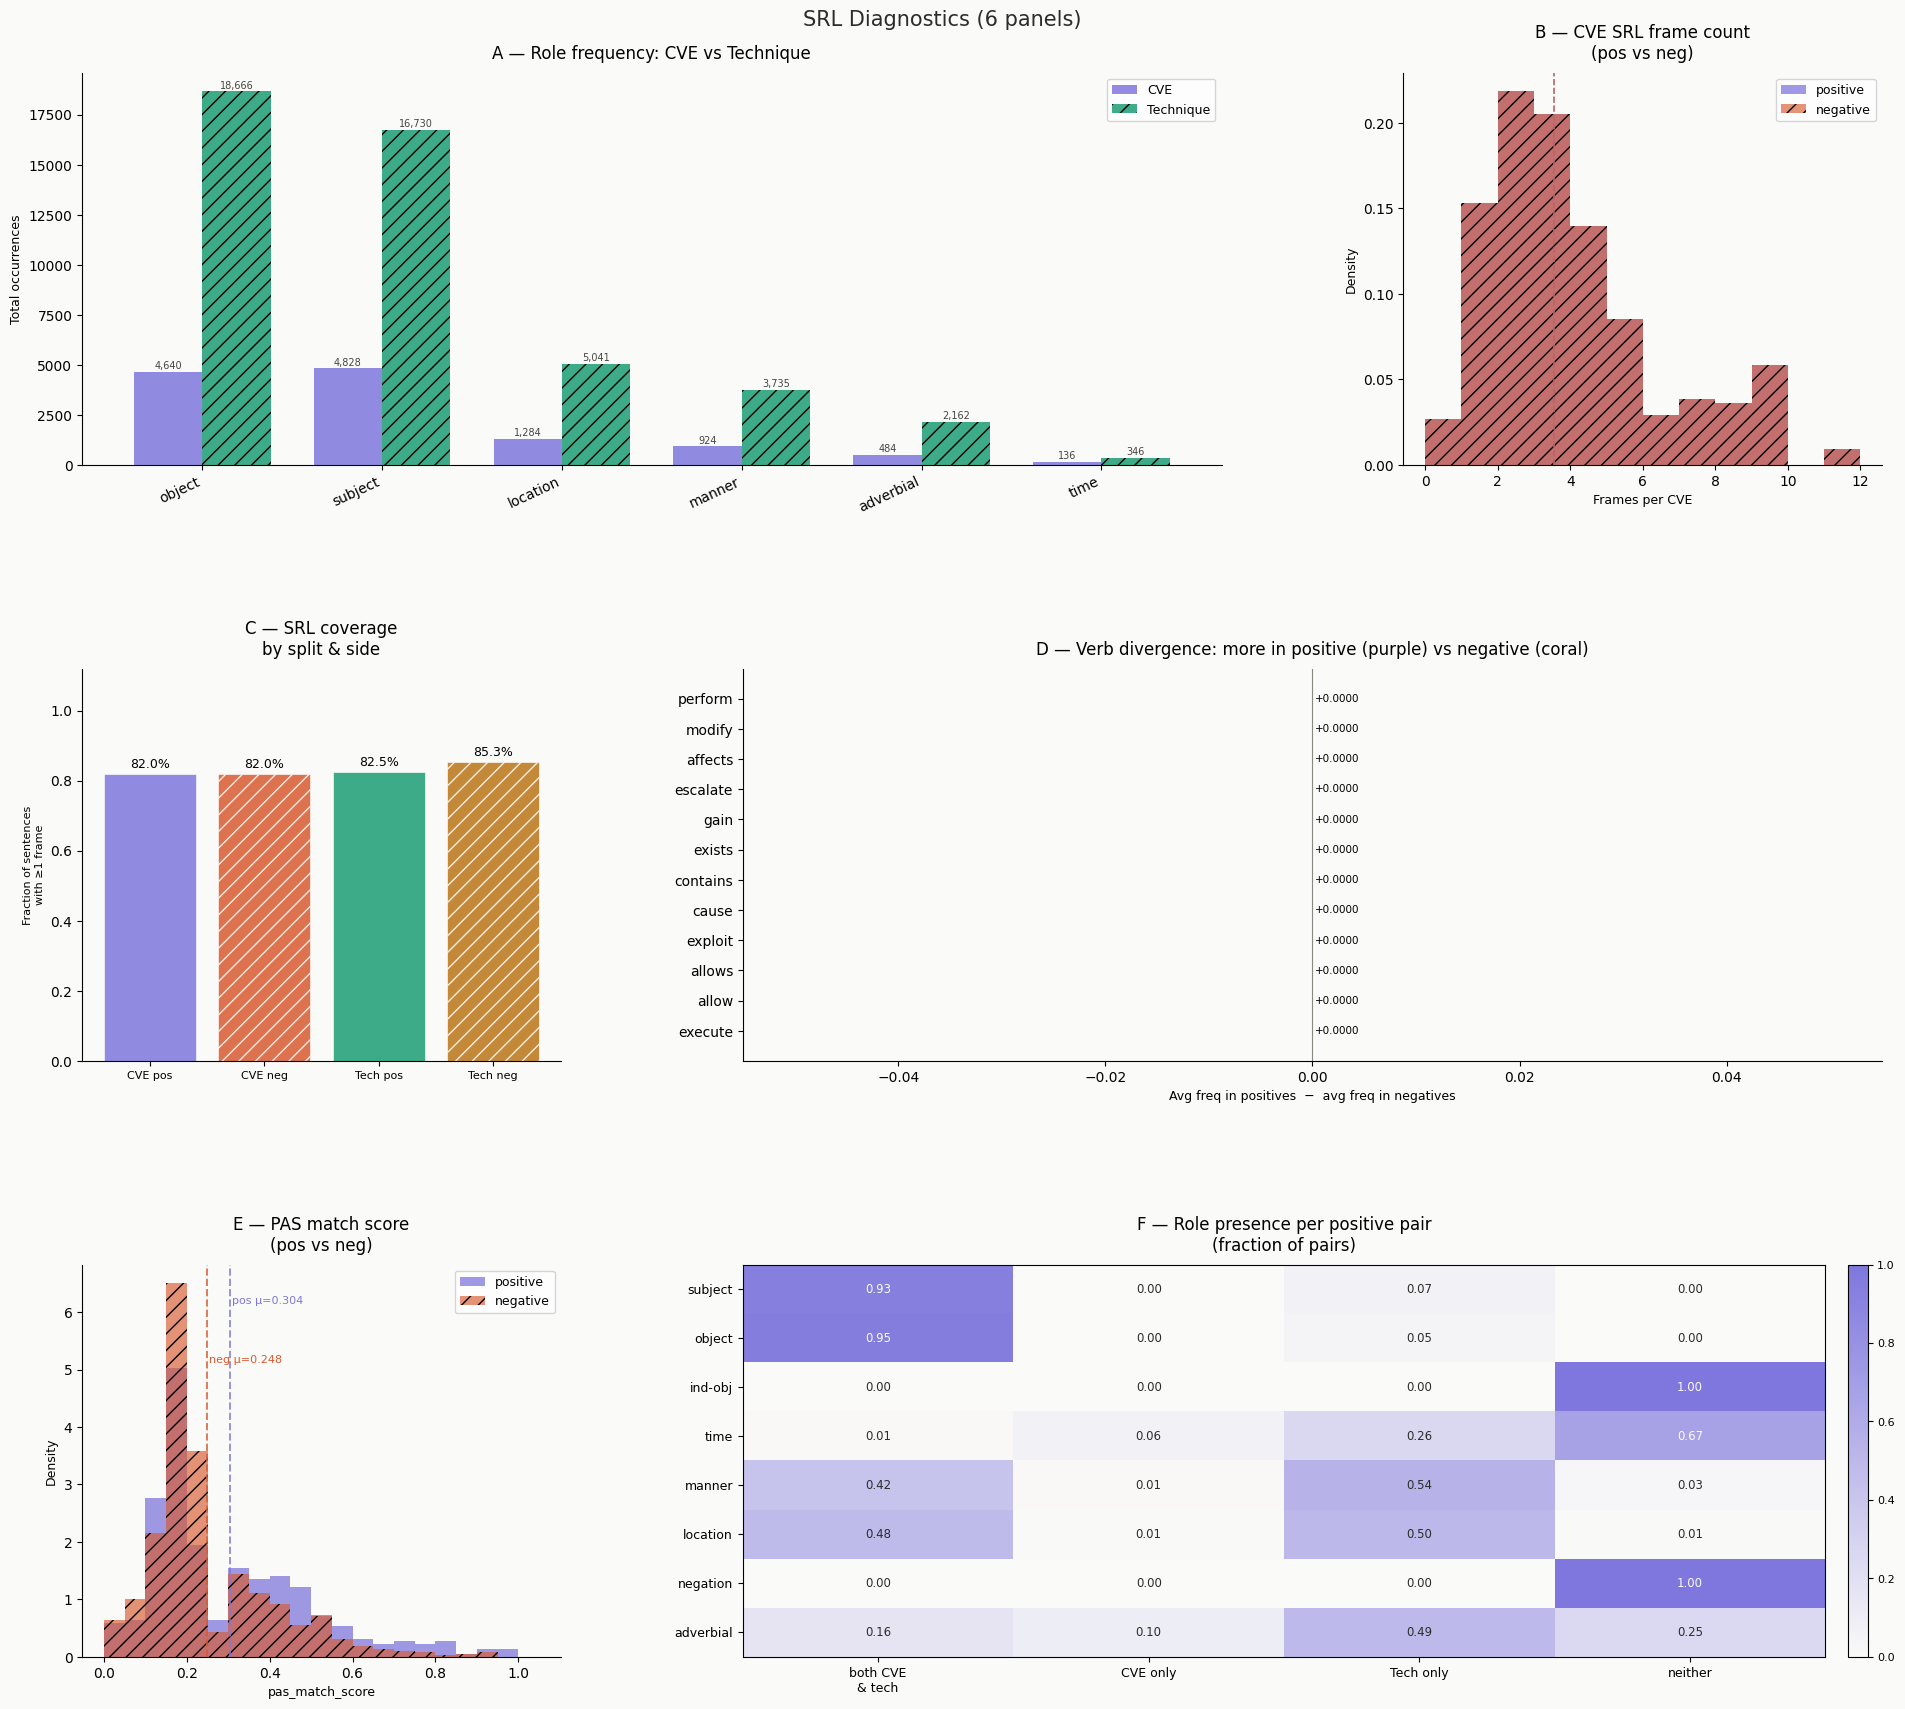

PANEL SUMMARY

A  Top role CVE:  subject
   Top role Tech: object
   ARG0 CVE/Tech ratio: 0.29x

B  Mean frames pos CVE: 3.55  neg CVE: 3.55

C  Coverage CVE pos: 82.0%  CVE neg: 82.0%
   Coverage Tech pos: 82.5%  Tech neg: 85.3%

D  Top positive-discriminating verb: 'execute'  gap=+0.0000
   Top negative-discriminating verb: 'execute'  gap=+0.0000

E  PAS gap (pos - neg): +0.0566  ✓ discriminative

F  Most co-present role (both sides): 'object'  rate=0.95
   Most CVE-only role: 'adverbial'  rate=0.10
   Most 'neither' role (SRL gap): 'ind-obj'  rate=1.00


In [22]:
## SRL Diagnostics Dashboard

import json, math, re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

#  helpers 

CANONICAL = {
    "ARG0": "subject",  "ARG1": "object",   "ARG2": "ind-obj",
    "ARGM-MNR": "manner", "ARGM-TMP": "time", "ARGM-LOC": "location",
    "ARGM-CAU": "cause",  "ARGM-NEG": "negation", "ARGM-MOD": "modal",
    "ARGM-ADV": "adverbial","ARGM-PRP": "purpose", "V": "verb",
}

def get_roles(srl_list, exclude_v=True):
    """Flat list of PropBank role labels from a srl_list."""
    roles = []
    for r in srl_list:
        for roles_dict in r["structured"].values():
            for role in roles_dict:
                if exclude_v and role == "V":
                    continue
                roles.append(role)
    return roles

def get_verb_texts(srl_list):
    return [vid.split("_")[0] for r in srl_list for vid in r["structured"]]

def coverage(srl_list):
    """Fraction of sentences that produced at least one SRL frame."""
    if not srl_list:
        return 0.0
    return sum(1 for r in srl_list if r["structured"]) / len(srl_list)

#  aggregate stats 

pos_pairs = [p for p in pairs if p["label"] == 1]
neg_pairs = [p for p in pairs if p["label"] == 0]

# Panel A role distribution across the whole dataset
cve_role_ctr   = Counter()
tech_role_ctr  = Counter()
for p in pairs:
    cve_role_ctr.update(get_roles(p["CVE_srl"]))
    tech_role_ctr.update(get_roles(p["Technique_srl"]))

# Panel B frame count distribution (pos vs neg)
pos_cve_frames  = [sum(len(r["structured"]) for r in p["CVE_srl"])  for p in pos_pairs]
neg_cve_frames  = [sum(len(r["structured"]) for r in p["CVE_srl"])  for p in neg_pairs]

# Panel C coverage: fraction of sentences with ≥1 frame (pos vs neg)
pos_cve_cov  = [coverage(p["CVE_srl"])       for p in pos_pairs]
neg_cve_cov  = [coverage(p["CVE_srl"])       for p in neg_pairs]
pos_tech_cov = [coverage(p["Technique_srl"]) for p in pos_pairs]
neg_tech_cov = [coverage(p["Technique_srl"]) for p in neg_pairs]

# Panel D top verbs in positive vs negative CVE pairs
pos_verbs = Counter(v for p in pos_pairs for v in get_verb_texts(p["CVE_srl"]))
neg_verbs = Counter(v for p in neg_pairs for v in get_verb_texts(p["CVE_srl"]))
all_top   = {v for v, _ in (pos_verbs + neg_verbs).most_common(15)}
top_verbs = sorted(all_top, key=lambda v: pos_verbs.get(v,0)+neg_verbs.get(v,0), reverse=True)[:12]

# Panel E PAS match score distribution (pos vs neg)
pos_pas = [p["pas_match_score"] for p in pos_pairs]
neg_pas = [p["pas_match_score"] for p in neg_pairs]

# Panel F per-role overlap heatmap (avg across pos pairs)
#   For each pair compute the set of roles in CVE ∩ Technique; average over all pos pairs
role_order = ["ARG0","ARG1","ARG2","ARGM-TMP","ARGM-MNR","ARGM-LOC","ARGM-NEG","ARGM-ADV"]

def role_presence(srl_list):
    s = set()
    for r in srl_list:
        for rdict in r["structured"].values():
            s.update(rdict.keys())
    return s

role_cve_only   = defaultdict(int)
role_tech_only  = defaultdict(int)
role_both       = defaultdict(int)
role_neither    = defaultdict(int)
n_pos = len(pos_pairs)

for p in pos_pairs:
    cve_roles  = role_presence(p["CVE_srl"])
    tech_roles = role_presence(p["Technique_srl"])
    for role in role_order:
        in_c = role in cve_roles
        in_t = role in tech_roles
        if in_c and in_t:     role_both[role]    += 1
        elif in_c:            role_cve_only[role] += 1
        elif in_t:            role_tech_only[role]+= 1
        else:                 role_neither[role]  += 1

#  matplotlib figure 

PURPLE = "#7F77DD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
GRAY   = "#888780"
LIGHT  = "#EEEDFE"

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor("#FAFAF8")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38,
                        top=0.94, bottom=0.06, left=0.07, right=0.97)

#  A: Role frequency bar chart 
ax_a = fig.add_subplot(gs[0, :2])
ax_a.set_facecolor("#FAFAF8")

roles_sorted = sorted(set(list(cve_role_ctr)+list(tech_role_ctr)),
                      key=lambda r: cve_role_ctr.get(r,0)+tech_role_ctr.get(r,0),
                      reverse=True)[:10]
x = np.arange(len(roles_sorted))
w = 0.38
bars1 = ax_a.bar(x - w/2, [cve_role_ctr[r]  for r in roles_sorted], w,
                  color=PURPLE, alpha=0.85, label="CVE")
bars2 = ax_a.bar(x + w/2, [tech_role_ctr[r] for r in roles_sorted], w,
                  color=TEAL,   alpha=0.85, label="Technique", hatch="//")
ax_a.set_xticks(x)
ax_a.set_xticklabels([CANONICAL.get(r, r) for r in roles_sorted],
                      fontsize=10, rotation=25, ha="right")
ax_a.set_title("A — Role frequency: CVE vs Technique", fontsize=12, fontweight="medium", pad=10)
ax_a.legend(fontsize=9)
ax_a.set_ylabel("Total occurrences", fontsize=9)
ax_a.spines[["top","right"]].set_visible(False)

# value labels
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax_a.text(bar.get_x() + bar.get_width()/2, h + max(list(cve_role_ctr.values()))*0.01,
                  f"{int(h):,}", ha="center", va="bottom", fontsize=7, color="#444441")

#  B: Frame count distribution 
ax_b = fig.add_subplot(gs[0, 2])
ax_b.set_facecolor("#FAFAF8")
bins = range(0, min(max(pos_cve_frames+neg_cve_frames)+2, 16))
ax_b.hist(pos_cve_frames, bins=bins, alpha=0.75, color=PURPLE, label="positive", density=True)
ax_b.hist(neg_cve_frames, bins=bins, alpha=0.65, color=CORAL,  label="negative",
          density=True, hatch="//")
ax_b.set_title("B — CVE SRL frame count\n(pos vs neg)", fontsize=12,
               fontweight="medium", pad=10)
ax_b.set_xlabel("Frames per CVE", fontsize=9)
ax_b.set_ylabel("Density", fontsize=9)
ax_b.legend(fontsize=9)
ax_b.spines[["top","right"]].set_visible(False)
ax_b.axvline(np.mean(pos_cve_frames), color=PURPLE, lw=1.2, ls="--", alpha=0.7)
ax_b.axvline(np.mean(neg_cve_frames), color=CORAL,  lw=1.2, ls="--", alpha=0.7)

#  C: Coverage comparison (grouped bar) 
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_facecolor("#FAFAF8")
labels_c  = ["CVE pos", "CVE neg", "Tech pos", "Tech neg"]
means_c   = [np.mean(pos_cve_cov),  np.mean(neg_cve_cov),
             np.mean(pos_tech_cov), np.mean(neg_tech_cov)]
colors_c  = [PURPLE, CORAL, TEAL, AMBER]
hatches_c = ["", "//", "", "//"]
bars_c = ax_c.bar(labels_c, means_c, color=colors_c,
                  alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, h_pat in zip(bars_c, hatches_c):
    bar.set_hatch(h_pat)
for bar, val in zip(bars_c, means_c):
    ax_c.text(bar.get_x()+bar.get_width()/2, val+0.01,
              f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="medium")
ax_c.set_ylim(0, 1.12)
ax_c.set_ylabel("Fraction of sentences\nwith ≥1 frame", fontsize=8)
ax_c.set_title("C — SRL coverage\nby split & side", fontsize=12, fontweight="medium", pad=10)
ax_c.spines[["top","right"]].set_visible(False)
ax_c.tick_params(axis="x", labelsize=8)

#  D: Top verb divergence chart 
ax_d = fig.add_subplot(gs[1, 1:])
ax_d.set_facecolor("#FAFAF8")
pos_vals  = np.array([pos_verbs.get(v, 0) / max(len(pos_pairs),1) for v in top_verbs])
neg_vals  = np.array([neg_verbs.get(v, 0) / max(len(neg_pairs),1) for v in top_verbs])
diverge   = pos_vals - neg_vals
y_pos = np.arange(len(top_verbs))
colors_d  = [PURPLE if d >= 0 else CORAL for d in diverge]
bars_d    = ax_d.barh(y_pos, diverge, color=colors_d, alpha=0.85, edgecolor="white")
ax_d.set_yticks(y_pos)
ax_d.set_yticklabels(top_verbs, fontsize=10)
ax_d.axvline(0, color=GRAY, lw=0.8)
ax_d.set_xlabel("Avg freq in positives  −  avg freq in negatives", fontsize=9)
ax_d.set_title("D — Verb divergence: more in positive (purple) vs negative (coral)",
               fontsize=12, fontweight="medium", pad=10)
ax_d.spines[["top","right"]].set_visible(False)
for bar, val in zip(bars_d, diverge):
    xpos = val + (0.0002 if val >= 0 else -0.0002)
    ha   = "left" if val >= 0 else "right"
    ax_d.text(xpos, bar.get_y()+bar.get_height()/2,
              f"{val:+.4f}", va="center", ha=ha, fontsize=7.5)

#  E: PAS match score histogram 
ax_e = fig.add_subplot(gs[2, 0])
ax_e.set_facecolor("#FAFAF8")
pas_bins = [i/20 for i in range(0, 22)]
ax_e.hist(pos_pas, bins=pas_bins, alpha=0.75, color=PURPLE, label="positive", density=True)
ax_e.hist(neg_pas, bins=pas_bins, alpha=0.65, color=CORAL,  label="negative",
          density=True, hatch="//")
ax_e.set_title("E — PAS match score\n(pos vs neg)", fontsize=12, fontweight="medium", pad=10)
ax_e.set_xlabel("pas_match_score", fontsize=9)
ax_e.set_ylabel("Density", fontsize=9)
ax_e.legend(fontsize=9)
ax_e.spines[["top","right"]].set_visible(False)
mu_pos = np.mean(pos_pas); mu_neg = np.mean(neg_pas)
ax_e.axvline(mu_pos, color=PURPLE, lw=1.4, ls="--", alpha=0.8)
ax_e.axvline(mu_neg, color=CORAL,  lw=1.4, ls="--", alpha=0.8)
ax_e.text(mu_pos+0.005, ax_e.get_ylim()[1]*0.9, f"pos μ={mu_pos:.3f}", color=PURPLE, fontsize=8)
ax_e.text(mu_neg+0.005, ax_e.get_ylim()[1]*0.75,f"neg μ={mu_neg:.3f}", color=CORAL,  fontsize=8)

#  F: Role co-occurrence heatmap (positive pairs only) 
ax_f = fig.add_subplot(gs[2, 1:])
ax_f.set_facecolor("#FAFAF8")
hmap_data = np.array([
    [role_both[r]/n_pos,    role_cve_only[r]/n_pos,
     role_tech_only[r]/n_pos, role_neither[r]/n_pos]
    for r in role_order
])
cmap_purple = LinearSegmentedColormap.from_list("pur", ["#FAFAF8", "#7F77DD"])
im = ax_f.imshow(hmap_data, aspect="auto", cmap=cmap_purple, vmin=0, vmax=1)
ax_f.set_xticks([0,1,2,3])
ax_f.set_xticklabels(["both CVE\n& tech", "CVE only", "Tech only", "neither"], fontsize=9)
ax_f.set_yticks(range(len(role_order)))
ax_f.set_yticklabels([CANONICAL.get(r,r) for r in role_order], fontsize=9)
ax_f.set_title("F — Role presence per positive pair\n(fraction of pairs)", fontsize=12,
               fontweight="medium", pad=10)
plt.colorbar(im, ax=ax_f, fraction=0.03, pad=0.02).ax.tick_params(labelsize=8)
for i in range(len(role_order)):
    for j in range(4):
        val = hmap_data[i, j]
        ax_f.text(j, i, f"{val:.2f}", ha="center", va="center",
                  fontsize=8.5, color="#2C2C2A" if val < 0.6 else "#FAFAF8",
                  fontweight="medium")

#  Global title 
fig.suptitle("SRL Diagnostics (6 panels)", fontsize=15, fontweight="medium",
             color="#2C2C2A", y=0.975)
plt.savefig("/kaggle/working/srl_diagnostics.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAF8")
plt.show()

#  Summary printout 
print("=" * 60)
print("PANEL SUMMARY")
print("=" * 60)
print(f"\nA  Top role CVE:  {CANONICAL.get(cve_role_ctr.most_common(1)[0][0],'?')}")
print(f"   Top role Tech: {CANONICAL.get(tech_role_ctr.most_common(1)[0][0],'?')}")
print(f"   ARG0 CVE/Tech ratio: "
      f"{cve_role_ctr['ARG0']/max(tech_role_ctr['ARG0'],1):.2f}x")

print(f"\nB  Mean frames pos CVE: {np.mean(pos_cve_frames):.2f}  "
      f"neg CVE: {np.mean(neg_cve_frames):.2f}")

print(f"\nC  Coverage CVE pos: {np.mean(pos_cve_cov):.1%}  "
      f"CVE neg: {np.mean(neg_cve_cov):.1%}")
print(f"   Coverage Tech pos: {np.mean(pos_tech_cov):.1%}  "
      f"Tech neg: {np.mean(neg_tech_cov):.1%}")

print(f"\nD  Top positive-discriminating verb: "
      f"'{top_verbs[np.argmax(diverge)]}'  gap={max(diverge):+.4f}")
print(f"   Top negative-discriminating verb: "
      f"'{top_verbs[np.argmin(diverge)]}'  gap={min(diverge):+.4f}")

print(f"\nE  PAS gap (pos - neg): {mu_pos - mu_neg:+.4f}  "
      f"{'✓ discriminative' if mu_pos > mu_neg else '✗ weak/inverted'}")

print(f"\nF  Most co-present role (both sides): "
      f"'{CANONICAL.get(role_order[np.argmax(hmap_data[:,0])],'?')}'  "
      f"rate={max(hmap_data[:,0]):.2f}")
print(f"   Most CVE-only role: "
      f"'{CANONICAL.get(role_order[np.argmax(hmap_data[:,1])],'?')}'  "
      f"rate={max(hmap_data[:,1]):.2f}")
print(f"   Most 'neither' role (SRL gap): "
      f"'{CANONICAL.get(role_order[np.argmax(hmap_data[:,3])],'?')}'  "
      f"rate={max(hmap_data[:,3]):.2f}")
print("=" * 60)



# INTERACTIVE INSPECTOR

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML

    TAG_COLORS = {
        "ARG0": ("#EEEDFE", "#3C3489"),
        "ARG1": ("#E1F5EE", "#085041"),
        "ARG2": ("#FAEEDA", "#633806"),
        "ARGM-TMP": ("#EAF3DE", "#27500A"),
        "ARGM-MNR": ("#FAECE7", "#712B13"),
        "ARGM-LOC": ("#E6F1FB", "#0C447C"),
        "ARGM-NEG": ("#FCEBEB", "#791F1F"),
        "ARGM-ADV": ("#F1EFE8", "#444441"),
        "V":        ("#2C2C2A", "#FFFFFF"),
    }

    def markup_to_html(markup_str):
        """Convert <SUB>…</SUB> markup string to coloured inline HTML spans."""
        TAG_TO_ROLE = {
            "SUB": "ARG0", "OBJ": "ARG1", "OB2": "ARG2",
            "TMP": "ARGM-TMP", "MNR": "ARGM-MNR", "LOC": "ARGM-LOC",
            "NEG": "ARGM-NEG", "ADV": "ARGM-ADV", "VRB": "V",
        }
        result = markup_str
        for short, role in TAG_TO_ROLE.items():
            bg, fg = TAG_COLORS.get(role, ("#eee", "#222"))
            result = re.sub(
                rf"<{short}>(.*?)</{short}>",
                lambda m, b=bg, f=fg, r=role:
                    f'<span style="background:{b};color:{f};padding:1px 6px;'
                    f'border-radius:4px;font-size:12px;margin:0 2px;'
                    f'font-weight:500" title="{r}">{m.group(1).strip()}</span>',
                result
            )
        return result

    def render_structured(srl_list):
        rows = []
        for result in srl_list:
            sent = result["sentence"]
            rows.append(
                f'<div style="font-size:12px;color:#888;margin:8px 0 2px">'
                f'<i>{sent}</i></div>'
            )
            for vid, roles in result["structured"].items():
                verb = vid.split("_")[0]
                role_spans = " ".join(
                    f'<span style="background:{TAG_COLORS.get(k,("#eee","#222"))[0]};'
                    f'color:{TAG_COLORS.get(k,("#eee","#222"))[1]};'
                    f'padding:1px 6px;border-radius:4px;font-size:11px;margin:0 2px">'
                    f'<b>{CANONICAL.get(k,k)}</b>: {v}</span>'
                    for k, v in roles.items()
                )
                rows.append(
                    f'<div style="margin:3px 0;font-size:12px">'
                    f'<span style="font-weight:500;color:#534AB7">[{verb}]</span> '
                    f'{role_spans}</div>'
                )
        return "\n".join(rows) if rows else "<i style='color:#aaa'>no frames</i>"

    #  widgets 
    idx_slider = widgets.IntSlider(
        value=0, min=0, max=len(pairs)-1, step=1,
        description="Pair #", layout=widgets.Layout(width="500px"),
        style={"description_width": "60px"}
    )
    label_toggle = widgets.ToggleButtons(
        options=[("All", "all"), ("Positive only", 1), ("Negative only", 0)],
        value="all", description="Filter:",
        style={"description_width": "50px", "button_width": "110px"}
    )
    out = widgets.Output()

    def _filtered_indices(flt):
        if flt == "all": return list(range(len(pairs)))
        return [i for i, p in enumerate(pairs) if p["label"] == flt]

    def show_pair(pair_idx):
        p = pairs[pair_idx]
        label_badge = (
            '<span style="background:#E1F5EE;color:#085041;padding:2px 10px;'
            'border-radius:12px;font-size:12px;font-weight:500">POSITIVE</span>'
            if p["label"] == 1 else
            '<span style="background:#FCEBEB;color:#791F1F;padding:2px 10px;'
            'border-radius:12px;font-size:12px;font-weight:500">NEGATIVE</span>'
        )
        pas   = p.get("pas_match_score", 0)
        vmc   = p.get("verb_match_count", 0)

        html = f"""
<div style="font-family:sans-serif;max-width:860px">
  <div style="display:flex;align-items:center;gap:12px;margin-bottom:12px">
    <span style="font-size:13px;font-weight:500;color:#2C2C2A">Pair {pair_idx}</span>
    {label_badge}
    <span style="font-size:12px;color:#888">
      PAS={pas:.3f} &nbsp;|&nbsp; verb_match={vmc}
      &nbsp;|&nbsp; CVE frames={sum(len(r['structured']) for r in p['CVE_srl'])}
      &nbsp;|&nbsp; Tech frames={sum(len(r['structured']) for r in p['Technique_srl'])}
    </span>
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px">
    <!-- CVE column -->
    <div style="border:0.5px solid #D3D1C7;border-radius:10px;padding:14px">
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:6px;
                  text-transform:uppercase;letter-spacing:.06em">CVE — {p['CVE_ID']}</div>
      <div style="font-size:12px;color:#2C2C2A;line-height:1.6;margin-bottom:10px">
        {p['CVE_text'][:300]}{'…' if len(p['CVE_text'])>300 else ''}
      </div>
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:4px">
        Markup</div>
      <div style="background:#F1EFE8;border-radius:6px;padding:8px;
                  font-size:12px;line-height:1.8;margin-bottom:10px">
        {markup_to_html(p['CVE_markup']) or '<i style="color:#aaa">empty</i>'}
      </div>
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:4px">
        Frames</div>
      {render_structured(p['CVE_srl'])}
    </div>

    <!-- Technique column -->
    <div style="border:0.5px solid #D3D1C7;border-radius:10px;padding:14px">
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:6px;
                  text-transform:uppercase;letter-spacing:.06em">
        Technique — {p['Technique_ID']}</div>
      <div style="font-size:12px;color:#2C2C2A;line-height:1.6;margin-bottom:10px">
        {p['Technique_text'][:300]}{'…' if len(p['Technique_text'])>300 else ''}
      </div>
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:4px">
        Markup</div>
      <div style="background:#F1EFE8;border-radius:6px;padding:8px;
                  font-size:12px;line-height:1.8;margin-bottom:10px">
        {markup_to_html(p['Technique_markup']) or '<i style="color:#aaa">empty</i>'}
      </div>
      <div style="font-size:11px;font-weight:500;color:#888;margin-bottom:4px">
        Frames</div>
      {render_structured(p['Technique_srl'])}
    </div>
  </div>
</div>"""
        with out:
            out.clear_output(wait=True)
            display(HTML(html))

    def on_slider(change):
        show_pair(change["new"])

    def on_toggle(change):
        valid = _filtered_indices(change["new"])
        idx_slider.max   = len(valid) - 1
        idx_slider.value = 0
        # remap so slider index → real pair index
        idx_slider._valid = valid
        show_pair(valid[0])

    # patch show_pair to respect filtered index list
    _orig_show = show_pair
    def show_pair(slider_val):
        valid = getattr(idx_slider, "_valid", list(range(len(pairs))))
        real  = valid[min(slider_val, len(valid)-1)]
        _orig_show(real)

    idx_slider.observe(lambda c: show_pair(c["new"]), names="value")
    label_toggle.observe(on_toggle, names="value")
    idx_slider._valid = list(range(len(pairs)))

    display(widgets.VBox([
        widgets.HBox([label_toggle, idx_slider]),
        out
    ]))
    show_pair(0)

except ImportError:
    print("ipywidgets not available — static dashboard saved to srl_diagnostics.png")

In [23]:
sample_pairs = pairs[:5]

NUM_SAMPLES = 5

for idx, p in enumerate(sample_pairs[:NUM_SAMPLES]):

    print("\n" + "=" * 120)
    print(f"SAMPLE {idx + 1}")
    print("=" * 120)

    print("\n[CVE ID]")
    print(p["CVE_ID"])

    print("\n[TECHNIQUE ID]")
    print(p["Technique_ID"])

    print("\n[LABEL]")
    print(p["label"])

    print("\n[CVE ORIGINAL]")
    print(p["CVE_text"])

    print("\n[CVE MARKUP]")
    print(p["CVE_markup"])

    print("\n[TECHNIQUE ORIGINAL]")
    print(p["Technique_text"])

    print("\n[TECHNIQUE MARKUP]")
    print(p["Technique_markup"])


SAMPLE 1

[CVE ID]
CVE-2008-4996

[TECHNIQUE ID]
T1485

[LABEL]
1

[CVE ORIGINAL]
** DISPUTED ** init in initramfs-tools 0.92f allows local users to overwrite arbitrary files via a symlink attack on the /tmp/initramfs.debug temporary file. NOTE: the vendor disputes this vulnerability, stating that "init is [used in] a single-user context; there's no possibility that this is exploitable."

[CVE MARKUP]
<SUB> DISPUTED * * init </SUB> <VRB> allows </VRB> <SUB> local users </SUB> <VRB> overwrite </VRB> <OBJ> arbitrary files </OBJ> <MNR> via a symlink attack on the /tmp / initramfs.debug temporary file </MNR> NOTE : the vendor disputes this vulnerability , stating that " init is [ used in ] a single - user context ; there 's no possibility that this is exploitable . "

[TECHNIQUE ORIGINAL]
Adversaries may destroy data and files on specific systems or in large numbers on a network to interrupt availability to systems, services, and network resources. Data destruction is likely to render sto